# 3D Gaussian Splatting in Open3D

Open3D supports real-time **3D Gaussian Splatting (3DGS)** rendering through a GPU compute
pipeline that projects, sorts, and composites Gaussian splats into a colour image alongside
Filament-rendered triangle-mesh geometry — with correct per-splat depth occlusion.

## Feature overview

### File I/O

| Format | Read | Write |
|--------|------|-------|
| Gaussian PLY (`.ply`) | `o3d.t.io.read_point_cloud` | `o3d.t.io.write_point_cloud` |
| Binary SPLAT (`.splat`) | `o3d.t.io.read_point_cloud` | `o3d.t.io.write_point_cloud` |

Both formats are detected automatically from the file extension and content.
Gaussian PLY files store log-scales and raw quaternions; binary SPLAT files store linear
scales.  `read_point_cloud` normalises both into the same in-memory layout. Note that SPLAT
files do not contain higher order spherical harmonics and so do not support view dependent appearence.

### Geometric transforms

Use `PointCloud.Scale` / `Rotate` / `Translate` for splats — **not** `Transform(4×4)`.
A general affine matrix cannot update the Gaussian covariance consistently.
Only **isotropic scaling, rotation, and translation** are fully supported:

| Operation | Positions | Quaternions | Linear scales | SH bands |
|-----------|-----------|-------------|---------------|----------|
| `Translate(t)` | ✓ shifted | — | — | — |
| `Rotate(R, c)` | ✓ rotated | ✓ left-multiplied by $q_R$ | — | ✓ all degrees rotated (Ivanic–Ruedenberg) |
| `Scale(s, c)` | ✓ scaled | — | ✓ multiplied by \|s\| | ✓ odd-degree blocks negated if s < 0 |
| `Transform(4×4)` | ✓ (warning) | ✗ unchanged | ✗ unchanged | ✗ unchanged |

`Rotate` is the most involved: it left-multiplies the stored unit quaternion and applies
the matching SO(3) rotation to every degree of `f_rest` using the
**Ivanic–Ruedenberg (1996)** recursive algorithm — including degree-3 coefficients —
so view-dependent colour stays correct after any rotation.

### Cropping

`PointCloud.Crop(AxisAlignedBoundingBox)` removes splats outside the box.  All attributes
of retained splats are preserved unchanged.

### Anti-aliasing (as in Mip Splatting)

When a 3DGS scene was **trained with anti-aliasing** (e.g. the Mip Splatting variant), set

```python
mat = o3d.visualization.rendering.MaterialRecord()
mat.shader = "gaussianSplat"
mat.gaussian_splat_antialias = True
```

This enables density compensation in the projection shader, multiplying each splat's alpha by
$\sqrt{\det(\Sigma_{\text{orig}}) / \det(\Sigma_{\text{blurred}})}$ to cancel the brightness
increase from the low-pass regulariser.  **Do not enable this for scenes trained without
anti-aliasing**, or they will appear too dark.

### Offscreen rendering

`open3d.visualization.rendering.OffscreenRenderer` renders the scene to CPU `Image` objects
without opening a window, suitable for batch pipelines and automated screenshots.
Both colour (`render_to_image`) and depth (`render_to_depth_image`) are supported.

---

This notebook demonstrates how to:

1. Download example assets (a Gaussian PLY scene, a binary SPLAT file, and two glTF meshes).
2. Detect geometry type with `open3d.io.read_file_geometry_type` before loading.
3. Load and inspect splat attributes from both `.ply` and `.splat` formats.
4. Apply SRT transforms using `_apply_srt_geometry` — identical code for splats and meshes.
5. Mix Gaussian splat scenes with textured triangle meshes in one `open3d.visualization.draw` window.
6. Render the scene offscreen to a colour image and a depth image.

The helper functions defined here match `draw_from_csv.py`, which lets you load any mix of
assets from a CSV manifest file from the command line.

In [1]:
from pathlib import Path
from typing import Tuple
import sys

import requests
import numpy as np
import open3d as o3d

## Download example assets

We fetch four assets that together form a mixed 3DGS + mesh scene:

| File | Type | Description |
|------|------|-------------|
| `mipnerf360_garden_crop_table.ply` | Gaussian PLY | Outdoor garden scene (MipNeRF-360) |
| `vase-f1992_13_2-150k-4096.glb` | glTF mesh | Smithsonian ceramic vase |
| `Lycaste_virginalis-150k-4096_std.glb` | glTF mesh | Smithsonian orchid |
| `nike.splat` | Binary SPLAT | Nike shoe |

Files are cached under Open3D's data directory so repeated runs skip the download.

In [2]:
def _download_example_assets():
    """Download example assets and return the directory they were saved to."""
    asset_urls = {
        "mipnerf360_garden_crop_table.ply": (
            "https://github.com/isl-org/open3d_downloads/releases/download/"
            "3dgs-1/mipnerf360_garden_crop_table.ply"
        ),
        "vase-f1992_13_2-150k-4096.glb": (
            "https://3d-api.si.edu/content/document/"
            "3d_package:a05dc7c9-7b6f-43f8-8830-69fe98718e4f/"
            "resources/vase-f1992_13_2-150k-4096.glb"
        ),
        "Lycaste_virginalis-150k-4096_std.glb": (
            "https://3d-api.si.edu/content/document/"
            "3d_package:5ff6e90a-4ddb-4eea-a69c-40970f85fbcb/"
            "resources/Lycaste_virginalis-150k-4096_std.glb"
        ),
        "nike.splat": (
            "https://huggingface.co/cakewalk/splat-data/resolve/"
            "8fa962a5c7088fff3149a658718b89c5eb2c9c26/nike.splat?download=true"
        ),
    }
    dataset = o3d.data.Dataset("3dgs_example_assets")
    out_path = Path(dataset.download_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    CHUNK = 64 * 1024 * 1024  # 64 MB
    for name, url in asset_urls.items():
        dest = out_path / name
        if dest.is_file():
            print(f"  {name}: already present")
            continue
        r = requests.get(url, stream=True, timeout=30)
        r.raise_for_status()
        print(f"  Downloading {name}", end="", flush=True)
        with open(dest, "wb") as fh:
            for chunk in r.iter_content(chunk_size=CHUNK):
                if chunk:
                    fh.write(chunk)
                    print(".", end="", flush=True)
        print(" done")
    return out_path


asset_dir = _download_example_assets()
print(f"\nAssets saved to: {asset_dir}")

  mipnerf360_garden_crop_table.ply: already present
  vase-f1992_13_2-150k-4096.glb: already present
  Lycaste_virginalis-150k-4096_std.glb: already present
  nike.splat: already present

Assets saved to: /home/ssheorey/open3d_data/download/3dgs_example_assets


## Loading 3DGS files — format overview

Before reading, `open3d.io.read_file_geometry_type` returns a bitmask describing
what a file contains.  This lets one loader handle any asset type:

| Flag | Meaning |
|------|---------|
| `CONTAINS_GAUSSIAN_SPLATS` | Gaussian splat data (`.ply` with `scale`/`rot` attrs, or `.splat`) |
| `CONTAINS_TRIANGLES` | Triangle mesh (`.glb`, `.obj`, `.stl`, …) |
| `CONTAINS_POINTS` | Generic point cloud |
| `CONTAINS_LINES` | Line set only |

Both `.ply` and `.splat` files are read with `open3d.t.io.read_point_cloud` into an
`open3d.t.geometry.PointCloud`.  The difference is in how attributes are stored on disk:
Gaussian PLY files store **log-scales** (exponentiated at load time) and raw quaternions,
while binary SPLAT files store **linear scales** directly.  Once loaded, both look identical.

In [3]:
ply_path   = asset_dir / "mipnerf360_garden_crop_table.ply"
splat_path = asset_dir / "nike.splat"
glb_path   = asset_dir / "vase-f1992_13_2-150k-4096.glb"

# Show the geometry-type flags for each file
for path in [ply_path, splat_path, glb_path]:
    gtype = o3d.io.read_file_geometry_type(str(path))
    flags = []
    if gtype & o3d.io.CONTAINS_GAUSSIAN_SPLATS: flags.append("GAUSSIAN_SPLATS")
    if gtype & o3d.io.CONTAINS_TRIANGLES:       flags.append("TRIANGLES")
    if gtype & o3d.io.CONTAINS_POINTS:          flags.append("POINTS")
    if gtype & o3d.io.CONTAINS_LINES:           flags.append("LINES")
    print(f"{path.name:50s}  flags: {' | '.join(flags) or hex(gtype)}")

mipnerf360_garden_crop_table.ply                    flags: GAUSSIAN_SPLATS | POINTS
nike.splat                                          flags: GAUSSIAN_SPLATS | POINTS
vase-f1992_13_2-150k-4096.glb                       flags: TRIANGLES | POINTS


## Inspecting Gaussian attributes

Tensor IO loads `.splat` / Gaussian `.ply` into `open3d.t.geometry.PointCloud`.
Printing the object summarises the point count and all attribute tensors.

Each splat stores:

| Attribute | Shape | Description |
|-----------|-------|-------------|
| `positions` | `(N, 3)` | Splat centre in world space |
| `rot` | `(N, 4)` | Unit quaternion `[w, x, y, z]` encoding orientation |
| `scale` | `(N, 3)` | Linear-space scale `[sx, sy, sz]` |
| `opacity` | `(N, 1)` | Sigmoid-mapped opacity in `[0, 1]` |
| `f_dc` | `(N, 3)` | Degree-0 spherical harmonic (DC colour) per RGB channel |
| `f_rest` | `(N, Nc, 3)` | Higher-degree SH coefficients; `Nc = (sh_degree+1)² − 1` |

Use `PointCloud.Scale` / `Rotate` / `Translate` to move splats: these operations update
`rot`, `scale`, and `f_rest` so the rendered appearance stays correct.
`Transform(4×4)` is **not** supported for splats — see the transforms section above.

In [4]:
# Load and inspect the Gaussian PLY scene
pcd_ply = o3d.t.io.read_point_cloud(str(ply_path))
print(f'=== {ply_path.name} ===')
print(pcd_ply)

print()

# Load and inspect the binary SPLAT file — same attributes, different on-disk encoding
pcd_splat = o3d.t.io.read_point_cloud(str(splat_path))
print(f'=== {splat_path.name} ===')
print(pcd_splat)

=== mipnerf360_garden_crop_table.ply ===
PointCloud on CPU:0 [773074 points (Float32)].
Attributes: rot (dtype = Float32, shape = {773074, 4}), opacity (dtype = Float32, shape = {773074, 1}), f_rest (dtype = Float32, shape = {773074, 15, 3}), scale (dtype = Float32, shape = {773074, 3}), f_dc (dtype = Float32, shape = {773074, 3}), normals (dtype = Float32, shape = {773074, 3}).

=== nike.splat ===
PointCloud on CPU:0 [270491 points (Float32)].
Attributes: opacity (dtype = Float32, shape = {270491, 1}), rot (dtype = Float32, shape = {270491, 4}), f_dc (dtype = Float32, shape = {270491, 3}), scale (dtype = Float32, shape = {270491, 3}).


## Scale → Rotate → Translate (SRT) transforms

For Gaussian splat `PointCloud`s, transforms must be applied as three **separate** operations
in **Scale → Rotate → Translate** order rather than with a single 4×4 matrix:

- `scale(s, center)` — multiplies all splat `scale` attributes by `|s|`; for a negative
  `s` it also negates the odd-degree SH blocks (point inversion).
- `rotate(R, center)` — left-multiplies stored quaternions by `q_R`; applies the SO(3)
  rotation to `f_rest` (Ivanic–Ruedenberg algorithm) so view-dependent colour stays correct.
- `translate(t)` — shifts `positions` only; rotations, scales, and SH are untouched.

The helper below accepts `(scale, rx_deg, ry_deg, rz_deg, tx, ty, tz)` and works identically
for `t.geometry.PointCloud` (Gaussian splats), `t.geometry.TriangleMesh`, legacy
`geometry.TriangleMesh`, and `geometry.PointCloud` — all expose the same SRT API.

In [5]:
def _apply_srt_geometry(
    geometry,
    srt: Tuple[float, float, float, float, float, float, float],
) -> None:
    """Apply Scale->Rotate->Translate to any Open3D geometry in-place.

    Parameters
    ----------
    geometry:
        Any geometry that exposes .scale(), .rotate(), .translate():
        t.geometry.PointCloud (Gaussian splats), t.geometry.TriangleMesh,
        legacy geometry.TriangleMesh, or geometry.PointCloud.
    srt:
        (scale, rx_deg, ry_deg, rz_deg, tx, ty, tz)
        Euler angles are XYZ order in degrees; translation is applied after rotation.
    """
    scale, rx, ry, rz, tx, ty, tz = srt
    rotation = np.array(
        o3d.geometry.get_rotation_matrix_from_xyz(
            np.deg2rad(np.array([rx, ry, rz], dtype=np.float64))
        )
    )
    translation = np.array([tx, ty, tz], dtype=np.float64)
    center = np.zeros(3, dtype=np.float64)
    geometry.scale(float(scale), center)
    geometry.rotate(rotation, center)
    geometry.translate(translation)

## Loading different geometry types

`_load_and_transform_row` uses the geometry-type bitmask to choose the right reader
and material, then immediately applies the SRT transform:

- **Gaussian splats** → `o3d.t.io.read_point_cloud` + `shader = "gaussianSplat"` material.
- **Triangle meshes** → `o3d.io.read_triangle_model`, which supports multi-material
  glTF / OBJ / FBX.  SRT is applied to each sub-mesh inside the model.
- **Point clouds** → `o3d.io.read_point_cloud` with default material.

Because the same `_apply_srt_geometry` call handles all three cases, you never need to
remember which API to use — the geometry-type flag does the dispatching.

In [6]:
def _load_and_transform_row(
    path: Path,
    srt: Tuple[float, float, float, float, float, float, float],
):
    """Load a geometry file and return a list of draw() dicts.

    Returns a list (one entry per geometry) ready to pass to
    o3d.visualization.draw, or None if the file is unsupported / missing.
    """
    if not path.is_file():
        print(f"[warning] File not found: {path}. Skipping.", file=sys.stderr)
        return None

    gtype = o3d.io.read_file_geometry_type(str(path))

    if gtype & o3d.io.CONTAINS_GAUSSIAN_SPLATS:
        # Gaussian splat — tensor PointCloud with gaussianSplat shader
        t_pcd = o3d.t.io.read_point_cloud(str(path))
        _apply_srt_geometry(t_pcd, srt)
        mat = o3d.visualization.rendering.MaterialRecord()
        mat.shader = "gaussianSplat"
        return [{"name": path.stem, "geometry": t_pcd, "material": mat}]

    if gtype & o3d.io.CONTAINS_TRIANGLES:
        # Multi-material model (glTF / OBJ / FBX); SRT applied to every sub-mesh
        model = o3d.io.read_triangle_model(str(path))
        for mesh_info in model.meshes:
            _apply_srt_geometry(mesh_info.mesh, srt)
        return [{"name": path.stem, "geometry": model}]

    if gtype & o3d.io.CONTAINS_POINTS:
        pcd = o3d.io.read_point_cloud(str(path))
        _apply_srt_geometry(pcd, srt)
        return [{"name": path.stem, "geometry": pcd}]

    print(f"[info] Skipping unsupported geometry type {gtype!r}: {path}", file=sys.stderr)
    return None

## Anti-aliasing (density compensation)

The `gaussianSplat` shader always adds a $0.3 I_{2\times2}$ low-pass filter to every
projected covariance to ensure sub-pixel splats cover at least one pixel.  This slightly
brightens the scene.

If the 3DGS scene was **trained with anti-aliasing** (e.g. the Mip-Splatting variant),
enable density compensation to cancel the brightness increase:

```python
mat.gaussian_splat_antialias = True
```

This multiplies each splat's alpha by
$\sqrt{\det(\Sigma_{\text{orig}}) / \det(\Sigma_{\text{blurred}})}$ in the projection shader.
**Only enable this for scenes that were trained with anti-aliasing** — enabling it for
standard scenes makes them appear too dark.

## Draw the full mixed scene

The manifest below places the garden Gaussian scene as a backdrop, two glTF mesh models
on the table (flipped 180° in X so they stand upright in the scene's Y-up coordinate
system), and the Nike shoe splat positioned in the foreground.

`o3d.visualization.draw` accepts a list of dicts with `"name"`, `"geometry"`, and
optionally `"material"` keys.  Gaussian splat entries must use `shader = "gaussianSplat"`.

In [7]:
# Scene manifest: (filename, scale, rx_deg, ry_deg, rz_deg, tx, ty, tz)
# Mirrors the CSV used by draw_from_csv.py
manifest = [
    ("mipnerf360_garden_crop_table.ply",       1.0,   0, 0, 0,  0.000, 0.000, 0.0),
    ("vase-f1992_13_2-150k-4096.glb",          0.5, 180, 0, 0, -0.200, 0.200, 1.0),
    ("Lycaste_virginalis-150k-4096_std.glb",   0.75, 180, 0, 0,  0.000, 0.425, 0.8),
    ("nike.splat",                             0.075, -15, 0, 0,  0.000, 0.470, 1.0),
]

draw_list = []
for i, (filename, *srt_values) in enumerate(manifest):
    path = asset_dir / filename
    srt = tuple(srt_values)
    out = _load_and_transform_row(path, srt)
    if not out:
        continue
    for d in out:
        d["name"] = f"l{i + 1}_{path.stem}"
    draw_list.extend(out)

print(f"Loaded {len(draw_list)} geometry entr{'y' if len(draw_list) == 1 else 'ies'}:")
for d in draw_list:
    print(f"  {d['name']}")

o3d.visualization.draw(
    draw_list,
    show_ui=True,
    title="3DGS + mesh scene",
    show_skybox=False,
    bg_color=(0.0, 0.0, 0.0, 1.0),
    ibl_intensity=100000,
)

Loaded 4 geometry entries:
  l1_mipnerf360_garden_crop_table
  l2_vase-f1992_13_2-150k-4096
  l3_Lycaste_virginalis-150k-4096_std
  l4_nike
[Open3D INFO] GaussianSplatOpenGLContext: Wayland session detected; using X11/GLX via XWayland for Filament compatibility.


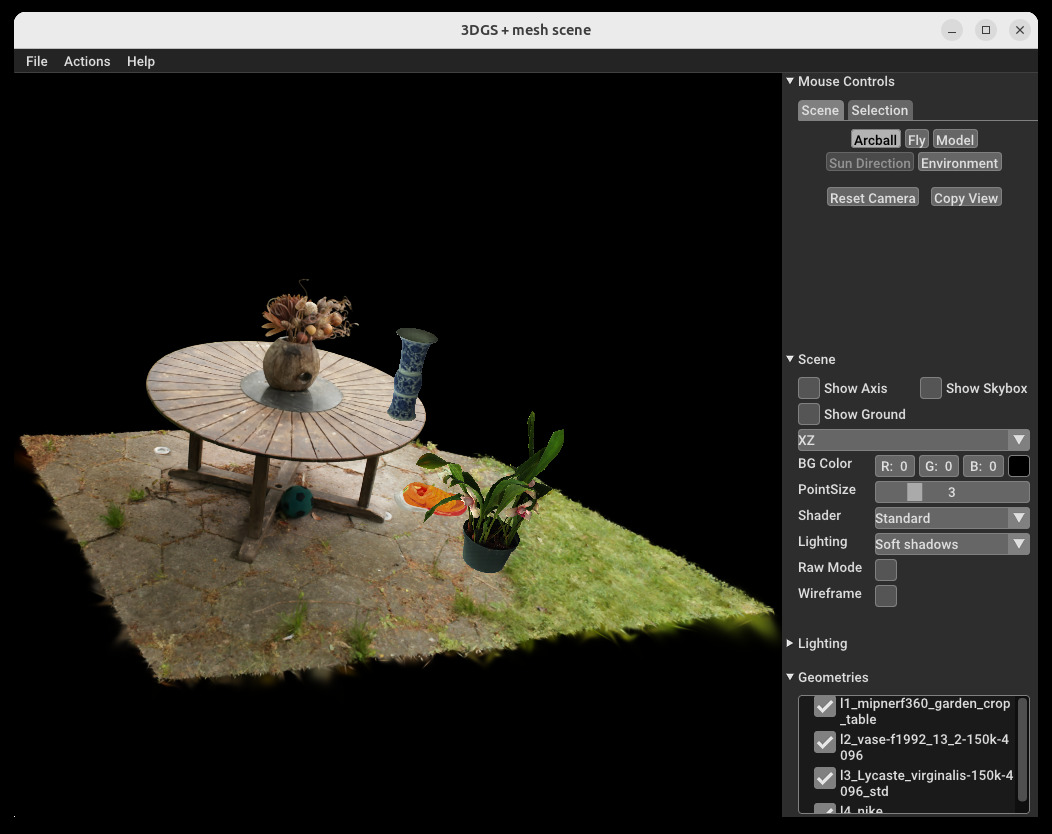

## Offscreen rendering — colour and depth images

`open3d.visualization.rendering.OffscreenRenderer` renders the same scene to CPU
`Image` objects without opening a window.  This is useful for automated pipelines,
batch processing, and documentation screenshots.

- **`render_to_image()`** returns an `open3d.geometry.Image` (RGB, uint8).
- **`render_to_depth_image(z_in_view_space=True)`** returns a float32 depth image in
  linear eye-space depth (metres).  With `z_in_view_space=False` (default) you get
  normalised device depth.

Both methods support Gaussian splat geometry through the same `gaussianSplat` material
and produce depth values that account for per-splat occlusion against any triangle mesh
geometry in the scene.

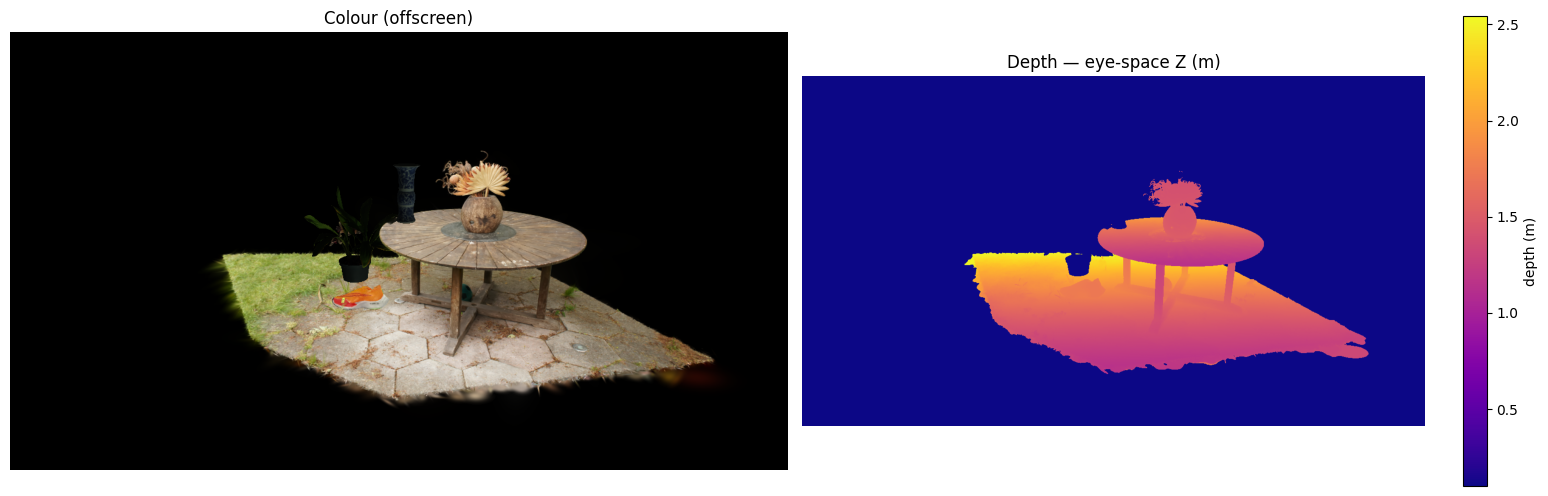

In [8]:
import matplotlib.pyplot as plt

WIDTH, HEIGHT = 1280, 720
renderer = o3d.visualization.rendering.OffscreenRenderer(WIDTH, HEIGHT)
renderer.scene.set_background([0.0, 0.0, 0.0, 1.0])

# Add all geometries from draw_list to the offscreen scene
for entry in draw_list:
    name = entry['name']
    geom = entry['geometry']
    mat  = entry.get('material', o3d.visualization.rendering.MaterialRecord())
    if isinstance(geom, o3d.visualization.rendering.TriangleMeshModel):
        renderer.scene.add_model(name, geom)
    else:
        renderer.scene.add_geometry(name, geom, mat)

# Position the camera to look at the centre of the scene from a sensible distance.
# setup_camera(fov_deg, center, eye, up) — eye is the camera position in world space.
bounds = renderer.scene.bounding_box
center = bounds.get_center()
extent = np.linalg.norm(bounds.get_max_bound() - bounds.get_min_bound())
eye    = center + np.array([0.0, -extent * 0.2, extent * 0.6])  # step back along +Z
renderer.setup_camera(60.0, center.tolist(), eye.tolist(), [0.0, -1.0, 0.0])

# Render colour image
colour_img = renderer.render_to_image()
colour_arr = np.asarray(colour_img)

# Render depth image (linear eye-space metres)
depth_img = renderer.render_to_depth_image(z_in_view_space=True)
depth_arr = np.asarray(depth_img)

# Clip to finite, positive depth values for display
valid = depth_arr[np.isfinite(depth_arr) & (depth_arr > 0)]
d_min, d_max = (valid.min(), valid.max()) if valid.size else (0.0, 1.0)

# Display inline with matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(colour_arr)
axes[0].set_title("Colour (offscreen)")
axes[0].axis("off")

im = axes[1].imshow(depth_arr, cmap="plasma", vmin=d_min, vmax=d_max)
fig.colorbar(im, ax=axes[1], label="depth (m)")
axes[1].set_title("Depth — eye-space Z (m)")
axes[1].axis("off")

plt.tight_layout()
plt.show()